In [1]:
# 4.1 Import Library & Konfigurasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             f1_score, accuracy_score, confusion_matrix,
                             classification_report, precision_score, recall_score)

# Konfigurasi Visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

# Path File (DISESUAIKAN UNTUK SLA)
MODEL_FILE = '../../outputs/SLA/sla_sentiment_clean_tanpa_perlakuan.csv'
GT_FILE = '../../outputs/evaluation/ground_truth_final.csv'
OUTPUT_DIR = '../../outputs/evaluation'

print(f"[INFO] Library dimuat. Konfigurasi evaluasi SLA siap.")

[INFO] Library dimuat. Konfigurasi evaluasi SLA siap.


In [2]:
# Cell 4.2 Load Data
df_gt = pd.read_csv(GT_FILE)
df_model = pd.read_csv(MODEL_FILE)

df_eval = df_gt[['no', 'ground_truth_category', 'ground_truth_scaled']].merge(
    df_model[['no', 'compound_score', 'sentiment']],
    on='no',
    how='inner'
)
print(f"[INFO] Data hasil merge: {len(df_eval)} baris")
print(df_eval.head())

[INFO] Data hasil merge: 450 baris
    no ground_truth_category  ground_truth_scaled  compound_score sentiment
0   50              positive                 0.20       -0.826809  negative
1   84              positive                 0.20        0.515993  positive
2   89              negative                -0.70       -0.960159  negative
3  101              positive                 0.20        0.853113  positive
4  121              positive                 0.15       -0.853113  negative


In [3]:
# 4.2.1 Validasi Data Ground Truth
df_gt

,no,timestamp,teks,teks_processed,ground_truth_mean,ground_truth_scaled,sd_annotator,ground_truth_category
0,50,2016-12-24T13:54:06.000Z,Komisi IX Ketua Komisi IX DPR RI merekomendasi...,komisi IX ketua komisi IX DPR RI merekomendasi...,0.8,0.20,0.447214,positive
1,84,2016-12-21T08:47:51.000Z,Dapilku Rumahku Reses dan silaturahim bersama ...,dapilku rumahku reses dan silaturahim bersama ...,0.8,0.20,0.447214,positive
2,89,2016-12-20T18:32:07.000Z,mengharukan wakil rakyat trlalu banyak waktuny...,mengharukan wakil rakyat terlalu banyak waktun...,-2.8,-0.70,0.447214,negative
3,101,2016-12-20T04:39:14.000Z,Ketua dan Para Wakil Ketua DPR RI PERLUNYA RUU...,ketua dan para wakil ketua DPR RI PERLUNYA RUU...,0.8,0.20,0.447214,positive
4,121,2016-12-18T04:07:09.000Z,Viva Anggota DPR Minta TNI AU Investigasi Kece...,viva anggota DPR meminta TNI AU investigasi ke...,0.6,0.15,0.547723,positive
...,...,...,...,...,...,...,...,...
445,13032,2025-11-11T14:24:58.000Z,Hai SahabatBahari Selasa November Badan Mutu K...,hai sahabatbahari selasa november badan mutu K...,0.4,0.10,0.547723,positive
446,13057,2025-11-10T15:20:53.000Z,gue nggak bodoh bodoh amat gue deserve punya p...,saya tidak bodoh bodoh sangat saya deserve pun...,-1.8,-0.45,1.303840,negative
447,13138,2025-11-05T04:02:54.000Z,Gpp lah boss DANA RESES DPRRI aja uang APBN UA...,enggak apa - apa lah bos DANA RESES DPRRI saja...,-3.6,-0.90,0.547723,negative
448,13174,2025-11-02T16:04:00.000Z,Sabtu November pukul WIB bertempat di Hotel Gr...,sabtu november pukul WIB bertempat di hotel gr...,0.8,0.20,0.447214,positive


In [4]:
# 4.2.2 Validasi Data Model
df_model

,no,timestamp,teks,teks_processed,sentiment,compound_score
0,50,2016-12-24T13:54:06.000Z,Komisi IX Ketua Komisi IX DPR RI merekomendasi...,komisi IX ketua komisi IX DPR RI merekomendasi...,negative,-0.826809
1,84,2016-12-21T08:47:51.000Z,Dapilku Rumahku Reses dan silaturahim bersama ...,dapilku rumahku reses dan silaturahim bersama ...,positive,0.515993
2,89,2016-12-20T18:32:07.000Z,mengharukan wakil rakyat trlalu banyak waktuny...,mengharukan wakil rakyat terlalu banyak waktun...,negative,-0.960159
3,101,2016-12-20T04:39:14.000Z,Ketua dan Para Wakil Ketua DPR RI PERLUNYA RUU...,ketua dan para wakil ketua DPR RI PERLUNYA RUU...,positive,0.853113
4,121,2016-12-18T04:07:09.000Z,Viva Anggota DPR Minta TNI AU Investigasi Kece...,viva anggota DPR meminta TNI AU investigasi ke...,negative,-0.853113
...,...,...,...,...,...,...
445,13032,2025-11-11T14:24:58.000Z,Hai SahabatBahari Selasa November Badan Mutu K...,hai sahabatbahari selasa november badan mutu K...,positive,0.878813
446,13057,2025-11-10T15:20:53.000Z,gue nggak bodoh bodoh amat gue deserve punya p...,saya tidak bodoh bodoh sangat saya deserve pun...,negative,-0.992656
447,13138,2025-11-05T04:02:54.000Z,Gpp lah boss DANA RESES DPRRI aja uang APBN UA...,enggak apa - apa lah bos DANA RESES DPRRI saja...,negative,-0.824397
448,13174,2025-11-02T16:04:00.000Z,Sabtu November pukul WIB bertempat di Hotel Gr...,sabtu november pukul WIB bertempat di hotel gr...,negative,-0.822463


In [5]:
# 4.3 Skala Evaluasi — Fix: tidak ada human_visual_score
y_true_scaled = df_eval['ground_truth_scaled']
y_pred_scaled = df_eval['compound_score']

# Untuk scatter plot nanti, y_human_visual = ground_truth_scaled
y_human_visual = df_eval['ground_truth_scaled']  # ← ini yang benar
y_model_pred = df_eval['compound_score']

print("[INFO] Persiapan metrik evaluasi selesai.")

[INFO] Persiapan metrik evaluasi selesai.


In [6]:
# 4.4 Hitung Pearson dan Spearman (Linear dan Monotonic Relationship)
# Hitung Pearson dan Spearman
pearson_r, p_val = pearsonr(y_true_scaled, y_pred_scaled)
spearman_rho, p_val_s = spearmanr(y_true_scaled, y_pred_scaled)

# Hitung Error Metrics
rmse = np.sqrt(mean_squared_error(y_true_scaled, y_pred_scaled))
mae = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2 = np.corrcoef(y_true_scaled, y_pred_scaled)[0, 1]**2 

print("=== HASIL EVALUASI CONTINUOUS SCORE (SLA+TANPA PERLAKUAN) ===")
print(f"Pearson Correlation (r)    : {pearson_r:.2f}")
print(f"Spearman Rank (rho)        : {spearman_rho:.2f}")
print(f"RMSE (Root Mean Sq. Error) : {rmse:.2f}")
print(f"MAE (Mean Abs. Error)      : {mae:.2f}")
print(f"R-Squared (R²)             : {r2:.2f}")

=== HASIL EVALUASI CONTINUOUS SCORE (SLA+TANPA PERLAKUAN) ===
Pearson Correlation (r)    : 0.56
Spearman Rank (rho)        : 0.54
RMSE (Root Mean Sq. Error) : 0.54
MAE (Mean Abs. Error)      : 0.44
R-Squared (R²)             : 0.31


In [7]:
# 4.5 Evaluasi Kategorikal dengan Threshold ±0.05
# Fungsi kategorisasi berdasarkan threshold standar ±0.05
def categorize(score):
    if score >= 0.20: return 'positive'
    elif score <= -0.20: return 'negative'
    else: return 'neutral'

df_eval['pred_class'] = df_eval['compound_score'].apply(categorize)
df_eval['gt_class'] = df_eval['ground_truth_category']

labels = ['negative', 'neutral', 'positive']

# Hitung Metrik Klasifikasi
acc = accuracy_score(df_eval['gt_class'], df_eval['pred_class'])
f1_macro = f1_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', labels=labels)

print("HASIL EVALUASI KLASIFIKASI (SLA+TANPA PERLAKUAN)")
print(f"Accuracy        : {acc:.2f}")
print(f"F1-Score (Macro): {f1_macro:.2f}")
print("-" * 50)
print("Classification Report SLA+TANPA PERLAKUAN:")
print(classification_report(df_eval['gt_class'], df_eval['pred_class'], target_names=labels, zero_division=0))

HASIL EVALUASI KLASIFIKASI (SLA+TANPA PERLAKUAN)
Accuracy        : 0.58
F1-Score (Macro): 0.54
--------------------------------------------------
Classification Report SLA+TANPA PERLAKUAN:
              precision    recall  f1-score   support

    negative       0.63      0.80      0.71       170
     neutral       0.44      0.27      0.33       123
    positive       0.56      0.57      0.57       157

    accuracy                           0.58       450
   macro avg       0.55      0.55      0.54       450
weighted avg       0.56      0.58      0.56       450



In [8]:
df_eval['error'] = df_eval['gt_class'] != df_eval['pred_class']
misclassified = df_eval[df_eval['error']].sample(50)
for _, row in misclassified.iterrows():
    print(f"Tweet: {df_gt[df_gt['no'] == row['no']]['teks_processed'].values[0][:100]}...")
    print(f"GT: {row['gt_class']} | Pred: {row['pred_class']} | Score: {row['compound_score']:.3f}")
    print("-" * 80)

Tweet: spirit RUU pertanahan integrasikan sektor SDA...
GT: negative | Pred: neutral | Score: 0.000
--------------------------------------------------------------------------------
Tweet: hal itu disampaikan desmond saat memimpin pertemuan tim kunjungan kerja reses komisi II DPR RI denga...
GT: neutral | Pred: negative | Score: -0.202
--------------------------------------------------------------------------------
Tweet: cth RUU pengaturan tempat peribadatan anggota DPR wah masa tempat ibadat diatur atur ini namanya int...
GT: negative | Pred: positive | Score: 0.498
--------------------------------------------------------------------------------
Tweet: RUU arsitek bakal atur mengenai jenjang pendidikan...
GT: neutral | Pred: positive | Score: 0.637
--------------------------------------------------------------------------------
Tweet: berikut berikut rekomendasi fraksi partai gerindra di terkait rancangan undang undang tentang pertan...
GT: neutral | Pred: positive | Score: 0.382
----

In [9]:
# 4.6 Tabel Metrik Utama
acc = accuracy_score(df_eval['gt_class'], df_eval['pred_class'])
prec = precision_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
rec = recall_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
f1 = f1_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)

metrics_df = pd.DataFrame([{
    'Konfigurasi': 'SLA+TANPA PERLAKUAN',
    'Accuracy': f"{acc:.2f}",
    'Precision (M)': f"{prec:.2f}",
    'Recall (M)': f"{rec:.2f}",
    'F1-Score (M)': f"{f1:.2f}"
}])

metrics_df

,Konfigurasi,Accuracy,Precision (M),Recall (M),F1-Score (M)
0,SLA+TANPA PERLAKUAN,0.58,0.55,0.55,0.54


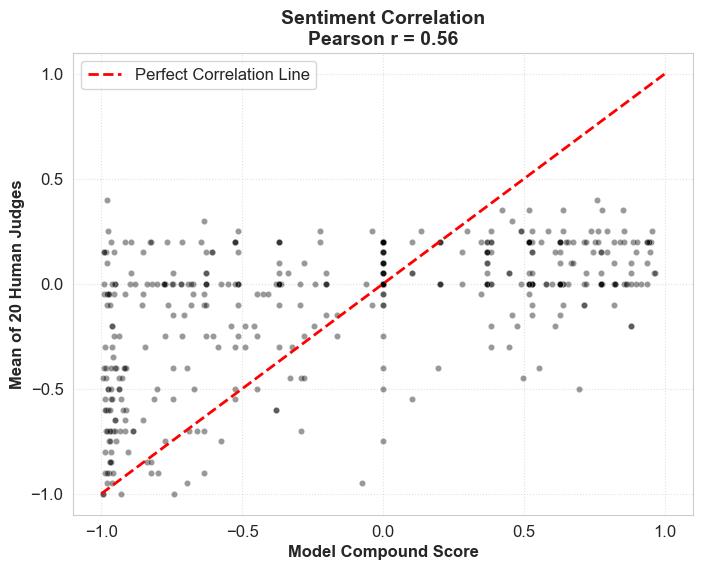

[INFO] Scatter plot tersimpan.


In [10]:
# 4.7 Visualisasi: Scatter Plot dan Regression Line
plt.figure(figsize=(8, 6))

# Scatter Plot: X = Model (-1,1), Y = Human (-1,1)
sns.scatterplot(x=y_model_pred, y=y_human_visual, alpha=0.4, color='black', s=20)

# Garis Merah: Garis regresi ideal (y = x * 4)
x_vals = np.linspace(-1, 1, 100)
y_vals = x_vals 
plt.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2, label='Perfect Correlation Line')

# Konfigurasi Sumbu
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xticks(np.arange(-1, 1.1, 0.5))
plt.yticks(np.arange(-1, 1.1, 0.5))

plt.xlabel('Model Compound Score', fontsize=12, fontweight='bold')
plt.ylabel('Mean of 20 Human Judges', fontsize=12, fontweight='bold')
plt.title(f'Sentiment Correlation\nPearson r = {pearson_r:.2f}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(f'{OUTPUT_DIR}/scatter_plot_SLA_tanpa_perlakuan.png', dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Scatter plot tersimpan.")

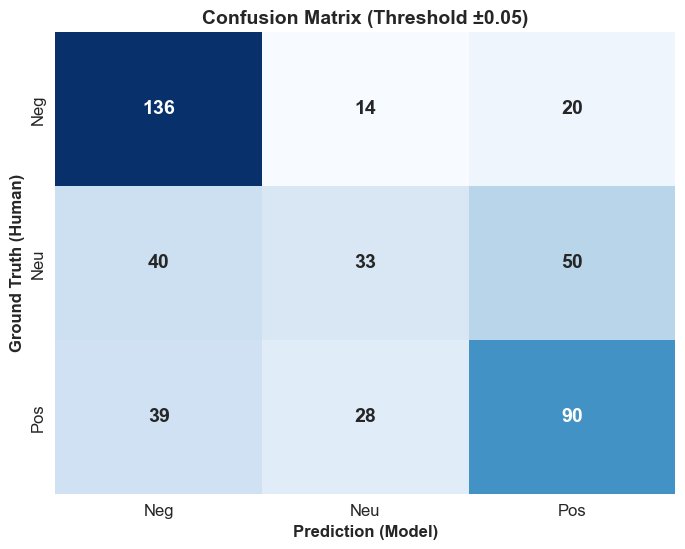

[INFO] Confusion matrix tersimpan.
[INFO] Proses evaluasi selesai!


In [11]:
# 4.8 Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))

# Hitung Confusion Matrix
cm = confusion_matrix(df_eval['gt_class'], df_eval['pred_class'], labels=labels)

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Neu', 'Pos'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix (Threshold ±0.05)', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth (Human)', fontsize=12, fontweight='bold')
plt.xlabel('Prediction (Model)', fontsize=12, fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_SLA_tanpa_perlakuan.png', dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Confusion matrix tersimpan.")
print("[INFO] Proses evaluasi selesai!")

In [12]:
# 4.9 Menyimpan Hasil
prec = precision_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
rec = recall_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)

metrics_df = pd.DataFrame([{
    'Konfigurasi': 'SLA+TANPA PERLAKUAN',
    'Accuracy': f"{acc:.2f}",
    'Precision (M)': f"{prec:.2f}",
    'Recall (M)': f"{rec:.2f}",
    'F1-Score (M)': f"{f1_macro:.2f}",
    'Pearson-r': f"{pearson_r:.2f}"
}])

# Simpan ke CSV
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'evaluation_metrics_SLA_tanpa_perlakuan.csv'), index=False)

# Simpan JSON Summary
eval_summary = {
    'konfigurasi': 'SLA+TANPA PERLAKUAN',
    'dataset_size': len(df_eval),
    'metrics': metrics_df.iloc[0].to_dict()
}
with open(os.path.join(OUTPUT_DIR, 'evaluation_summary_SLA_tanpa_perlakuan.json'), 'w') as f:
    json.dump(eval_summary, f, indent=2)

print("\n[INFO] Evaluasi SLA+TANPA PERLAKUAN Selesai. Data metrik telah disimpan.")
metrics_df


[INFO] Evaluasi SLA+TANPA PERLAKUAN Selesai. Data metrik telah disimpan.


,Konfigurasi,Accuracy,Precision (M),Recall (M),F1-Score (M),Pearson-r
0,SLA+TANPA PERLAKUAN,0.58,0.55,0.55,0.54,0.56
